In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('../data/combined_bbb_classification.csv')
df

,name,smiles,BBB,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,sulphasalazine,O=C(O)c1cc(N=Nc2ccc(S(=O)(=O)Nc3ccccn3)cc2)ccc1O,0,12.341010,12.341010,0.023055,-3.794932,0.540588,11.428571,398.400,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,moxalactam,COC1(NC(=O)C(C(=O)O)c2ccc(O)cc2)C(=O)N2C(C(=O)...,0,13.190522,13.190522,0.042537,-2.144257,0.133795,22.000000,520.480,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,clioquinol,Oc1c(I)cc(Cl)c2cccnc12,0,9.654043,9.654043,0.195000,0.195000,0.758308,10.615385,305.502,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,bbcpd11 (cimetidine analog) (y-g13),CCNC(=NCCSCc1ncccc1Br)NC#N,0,8.544584,8.544584,0.532052,0.532052,0.272365,10.894737,342.266,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,schembl614298,CN1CC[C@]23c4c5ccc(OC6O[C@H](C(=O)O)[C@@H](O)[...,0,11.445328,11.445328,0.165306,-1.798901,0.346256,45.303030,461.467,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9632,licostinel,C1=C(Cl)C(=C(C2=C1NC(=O)C(N2)=O)[N+](=O)[O-])Cl,1,11.106041,11.106041,0.037685,-1.000936,0.466075,10.705882,276.035,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9633,ademetionine(adenosyl-methionine),[C@H]3([N]2C1=C(C(=NC=N1)N)N=C2)[C@@H]([C@@H](...,1,10.698110,10.698110,0.210831,-1.284365,0.344970,27.703704,398.445,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9634,mesocarb,[O+]1=N[N](C=C1[N-]C(NC2=CC=CC=C2)=O)C(CC3=CC=...,1,11.877182,11.877182,0.094708,-0.499803,0.685827,11.708333,322.368,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
9635,tofisoline,C1=C(OC)C(=CC2=C1C(=[N+](C(=C2CC)C)[NH-])C3=CC...,1,8.783737,8.783737,0.616526,0.616526,0.588327,10.785714,382.460,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [24]:
desc = list(df.columns)
count = (df[desc] == 0).any(axis=1).sum()
print(count)
rows_with_zero = df[df[desc].eq(0).any(axis=1)]


9630


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set(style="whitegrid", font_scale=1.3)

# Create output directory
OUT = Path("eda_figures")
OUT.mkdir(exist_ok=True)


In [32]:
# Helper function to detect closest column name by keyword
def detect_col(possible_names, df):
    for name in df.columns:
        for p in possible_names:
            if p.lower() in name.lower():
                return name
    return None

mw_col   = "MolWt"
logp_col = detect_col(["logp", "xlogp", "alogp"], df)
tpsa_col = detect_col(["tpsa", "polar surface"], df)
hbd_col  = detect_col(["hbd", "donor"], df)
hba_col  = detect_col(["hba", "acceptor"], df)



In [33]:
print(type(mw_col))
print(type(logp_col))

<class 'str'>
<class 'str'>


In [27]:
# Works for BBB, permeable, binary labels, etc.
if "BBB" in df.columns:
    df["BBB_label"] = df["BBB"].replace({"Yes": 1, "No": 0}).astype(int)
else:
    raise ValueError("Dataset must contain BBB column.")


In [34]:
# Compute Lipinski only if all needed columns exist
if all(col is not None for col in [mw_col, logp_col, hbd_col, hba_col]):
    df["lipinski_pass"] = (
        (df[mw_col] <= 500) &
        (df[logp_col] <= 5) &
        (df[hbd_col] <= 5) &
        (df[hba_col] <= 10)
    ).astype(int)
else:
    print("Lipinski cannot be computed — missing one or more columns:", 
          mw_col, logp_col, hbd_col, hba_col)
    df["lipinski_pass"] = np.nan


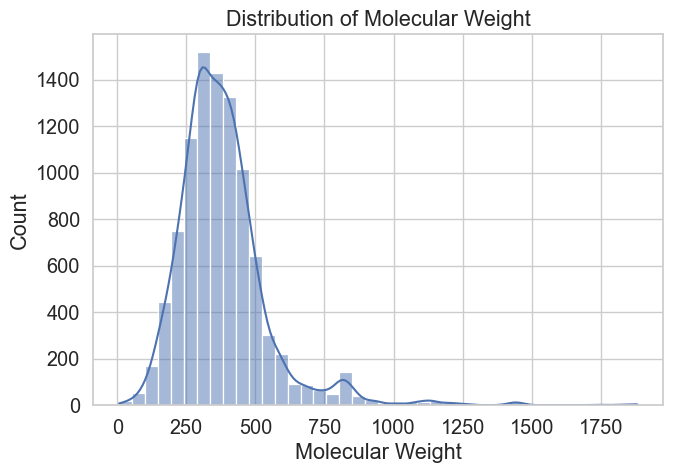

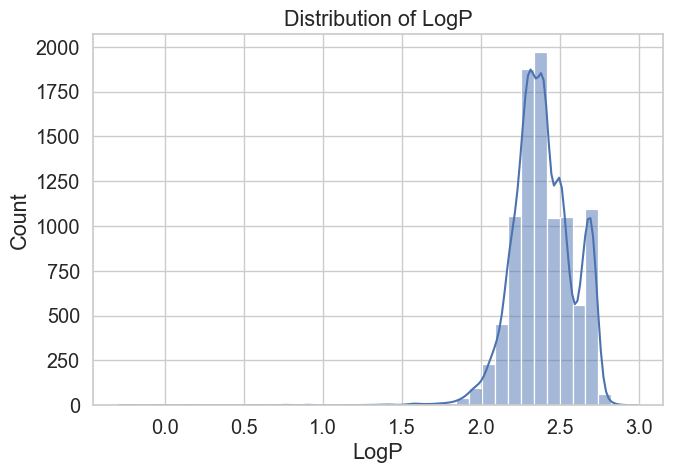

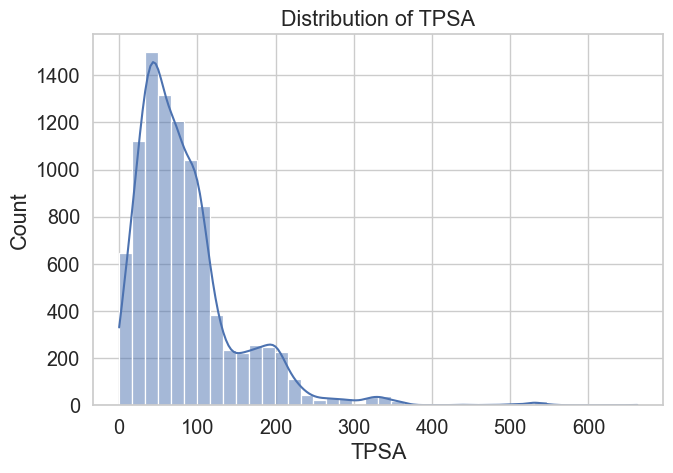

In [36]:
for col, name in [(mw_col, "Molecular Weight"),
                  (logp_col, "LogP"),
                  (tpsa_col, "TPSA")]:

    if col:
        plt.figure(figsize=(7,5))
        sns.histplot(df[col], kde=True, bins=40)
        plt.title(f"Distribution of {name}")
        plt.xlabel(name)
        plt.tight_layout()
        plt.savefig(OUT / f"hist_{col}.png", dpi=300)
        plt.show()

        
#TODO - can make 3d?

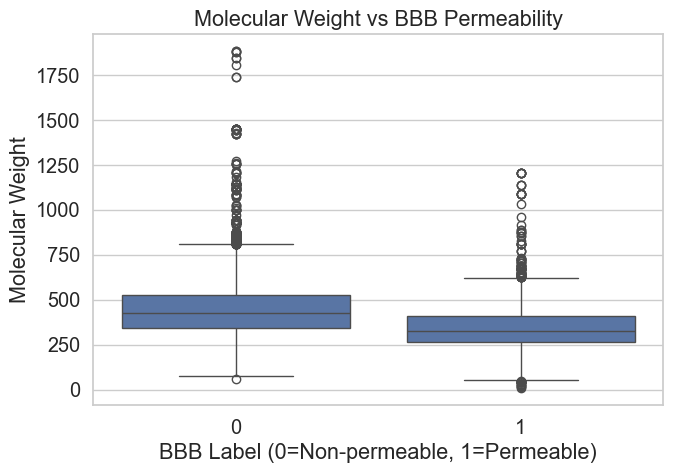

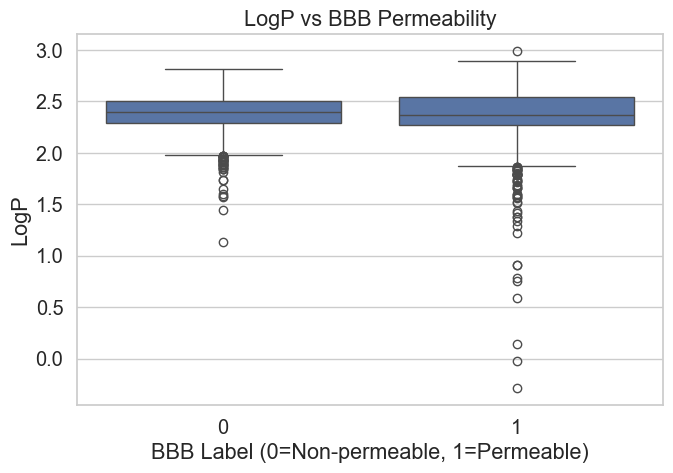

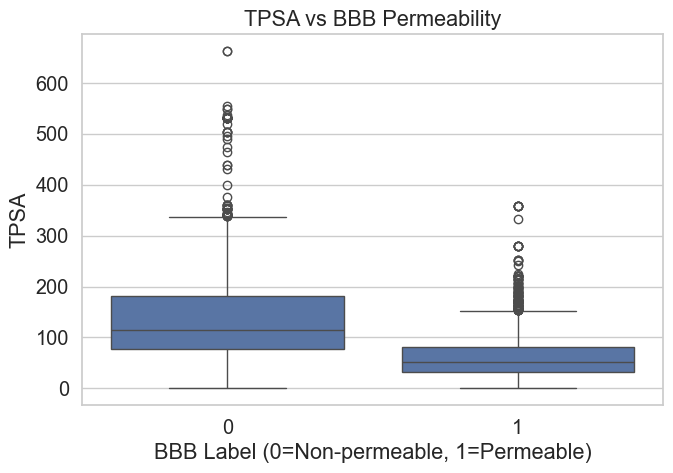

In [37]:
for col, name in [(mw_col, "Molecular Weight"),
                  (logp_col, "LogP"),
                  (tpsa_col, "TPSA")]:

    if col:
        plt.figure(figsize=(7,5))
        sns.boxplot(data=df, x="BBB_label", y=col)
        plt.title(f"{name} vs BBB Permeability")
        plt.xlabel("BBB Label (0=Non-permeable, 1=Permeable)")
        plt.ylabel(name)
        plt.tight_layout()
        plt.savefig(OUT / f"box_{col}_by_BBB.png", dpi=300)
        plt.show()


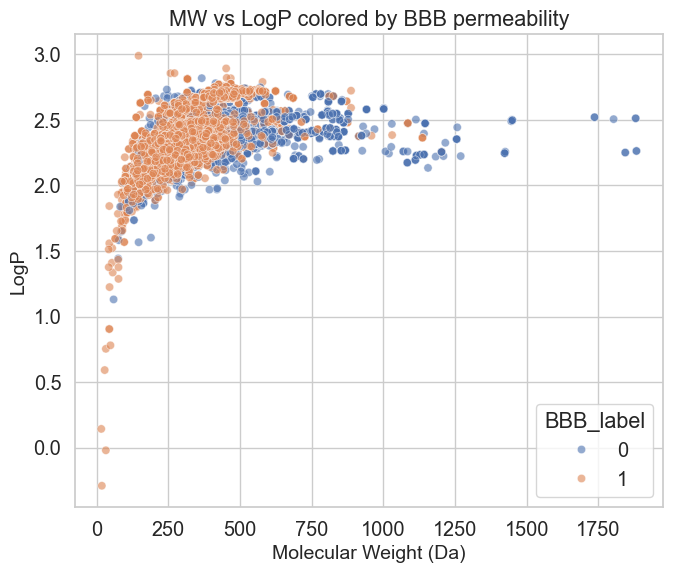

In [41]:
if mw_col and logp_col:
    plt.figure(figsize=(7,6))
    ax = sns.scatterplot(
        data=df,
        x=mw_col,
        y=logp_col,
        hue="BBB_label",
        alpha=0.6
    )
    
    # custom axis labels
    ax.set_xlabel("Molecular Weight (Da)", fontsize=14)
    ax.set_ylabel("LogP", fontsize=14)

    plt.title("MW vs LogP colored by BBB permeability")
    plt.tight_layout()
    plt.savefig(OUT / "scatter_mw_logp.png", dpi=300)
    plt.show()


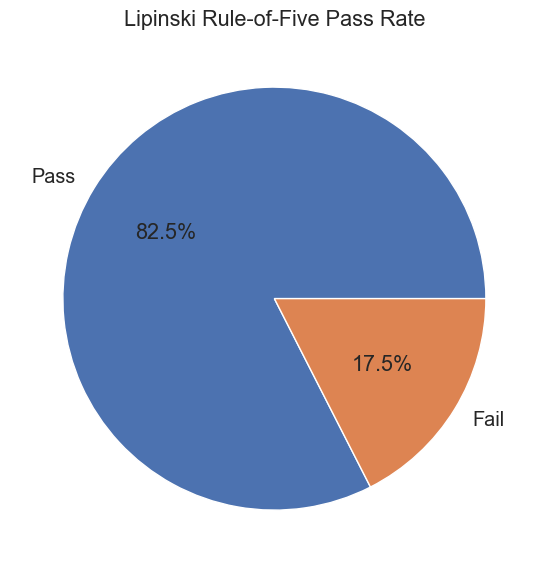

In [42]:
if "lipinski_pass" in df.columns and df["lipinski_pass"].notna().any():
    plt.figure(figsize=(6,6))
    df["lipinski_pass"].value_counts().rename({1: "Pass", 0: "Fail"}).plot(
        kind="pie", autopct="%.1f%%"
    )
    plt.title("Lipinski Rule-of-Five Pass Rate")
    plt.ylabel("")
    plt.tight_layout()
    plt.savefig(OUT / "pie_lipinski.png", dpi=300)
    plt.show()


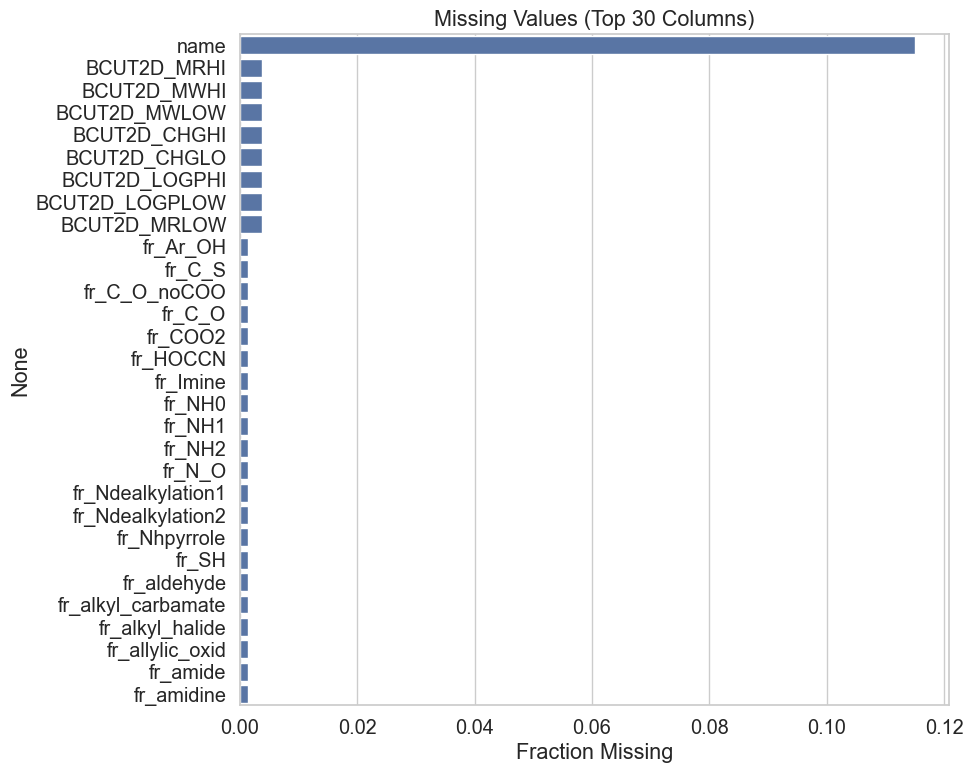

In [43]:
missing = df.isnull().mean().sort_values(ascending=False).head(30)

plt.figure(figsize=(10,8))
sns.barplot(x=missing.values, y=missing.index)
plt.xlabel("Fraction Missing")
plt.title("Missing Values (Top 30 Columns)")
plt.tight_layout()
plt.savefig(OUT / "missingness_top30.png", dpi=300)
plt.show()


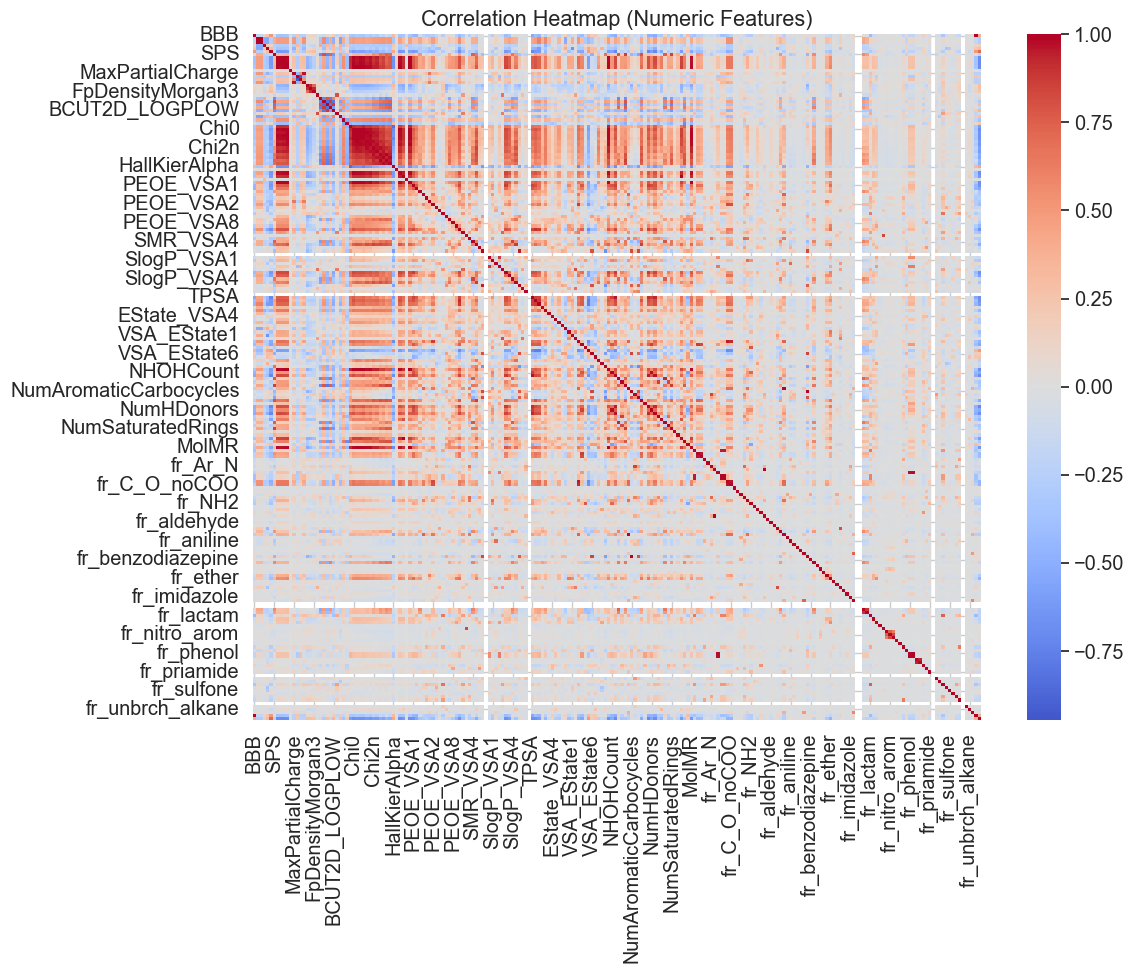

In [44]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols].corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (Numeric Features)")
plt.tight_layout()
plt.savefig(OUT / "corr_heatmap.png", dpi=300)
plt.show()


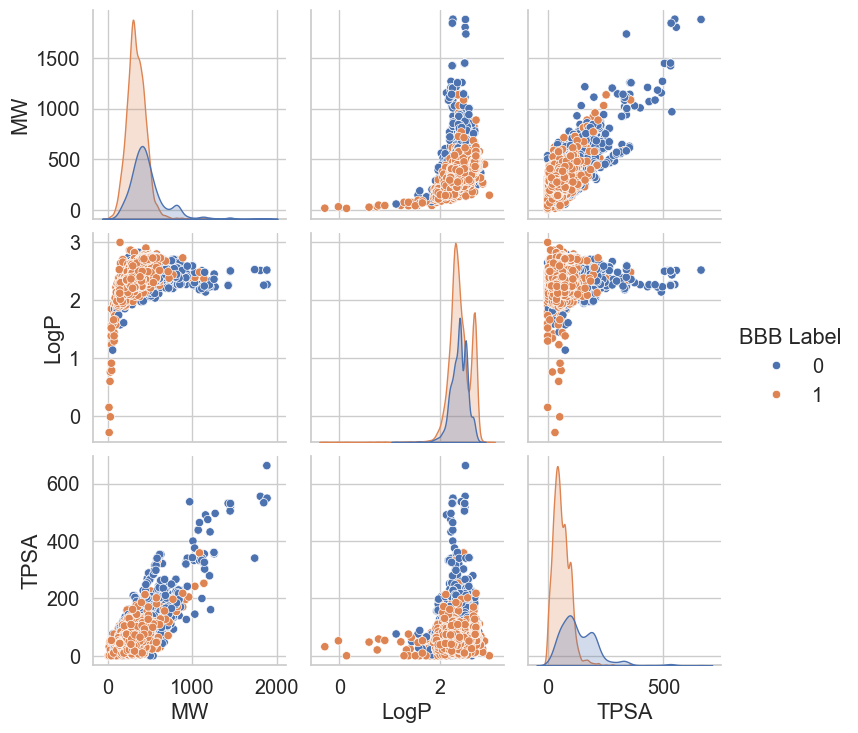

In [ ]:
selected = [c for c in [mw_col, logp_col, tpsa_col] if c] + ["BBB_label"]
selected = list(dict.fromkeys(selected)) 
rename_dict = {
    mw_col: "MW",
    logp_col: "LogP",
    tpsa_col: "TPSA",
    "BBB_label": "BBB Label"
}

# Subset the dataframe
df_subset = df[selected].rename(columns=rename_dict)

sns.pairplot(df_subset, hue="BBB Label", diag_kind="kde")
plt.savefig(OUT / "pairplot_features.png", dpi=300)
plt.show()


KeyError: np.int64(0)

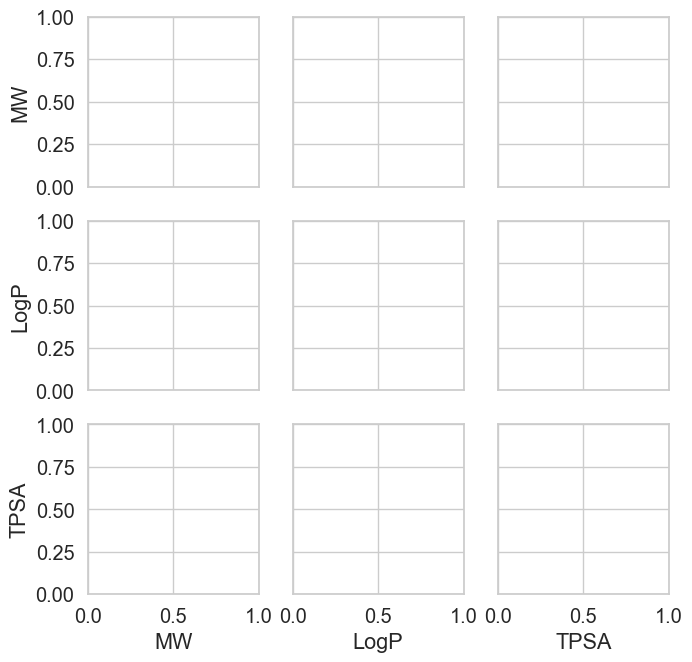

In [49]:
sns.pairplot(
    df_subset,
    hue="BBB Label",
    diag_kind="kde",
    palette={"Yes": "red", "No": "blue"}  # map your class labels to colors
)


In [11]:
df[df["name"] == "ibuprofen"]

,name,smiles,BBB,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
7942,ibuprofen,CC(C)Cc1ccc(cc1)C(C)C(O)=O,1,10.762425,10.762425,0.418426,-0.771658,0.8216,12.8,206.285,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [10]:
df[df["name"] == "flurbiprofen"]

,name,smiles,BBB,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
27,flurbiprofen,CC(C(=O)O)c1ccc(-c2ccccc2)c(F)c1,1,13.966636,13.966636,0.396481,-0.95661,0.89375,12.111111,244.265,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [9]:
df.loc[df["name"] == "flurbiprofen", "BBB"] = 1
df.loc[df["name"] == "ibuprofen", "BBB"] = 1
df.loc[df["name"] == "indomethacin", "BBB"] = 1

In [13]:
df.to_csv("../data/combined_bbb_classification_fixed.csv")